## Part 1: Data Preparation

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from matplotlib.colors import LinearSegmentedColormap

RANDOM_STATE = 42

In [2]:
df = pd.read_excel("Dry_Bean_Dataset.xlsx")
df.head()

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272750,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13611 entries, 0 to 13610
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area             13611 non-null  int64  
 1   Perimeter        13611 non-null  float64
 2   MajorAxisLength  13611 non-null  float64
 3   MinorAxisLength  13611 non-null  float64
 4   AspectRation     13611 non-null  float64
 5   Eccentricity     13611 non-null  float64
 6   ConvexArea       13611 non-null  int64  
 7   EquivDiameter    13611 non-null  float64
 8   Extent           13611 non-null  float64
 9   Solidity         13611 non-null  float64
 10  roundness        13611 non-null  float64
 11  Compactness      13611 non-null  float64
 12  ShapeFactor1     13611 non-null  float64
 13  ShapeFactor2     13611 non-null  float64
 14  ShapeFactor3     13611 non-null  float64
 15  ShapeFactor4     13611 non-null  float64
 16  Class            13611 non-null  object 
dtypes: float64(1

In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Area,13611.0,53048.284549,29324.095717,20420.000000,36328.000000,44652.000000,61332.000000,254616.000000
Perimeter,13611.0,855.283459,214.289696,524.736000,703.523500,794.941000,977.213000,1985.370000
MajorAxisLength,13611.0,320.141867,85.694186,183.601165,253.303633,296.883367,376.495012,738.860153
MinorAxisLength,13611.0,202.270714,44.970091,122.512653,175.848170,192.431733,217.031741,460.198497
AspectRation,13611.0,1.583242,0.246678,1.024868,1.432307,1.551124,1.707109,2.430306
Eccentricity,13611.0,0.750895,0.092002,0.218951,0.715928,0.764441,0.810466,0.911423
ConvexArea,13611.0,53768.200206,29774.915817,20684.000000,36714.500000,45178.000000,62294.000000,263261.000000
EquivDiameter,13611.0,253.064220,59.177120,161.243764,215.068003,238.438026,279.446467,569.374358
Extent,13611.0,0.749733,0.049086,0.555315,0.718634,0.759859,0.786851,0.866195
Solidity,13611.0,0.987143,0.004660,0.919246,0.985670,0.988283,0.990013,0.994677


### Duplicates

In [5]:
print(f"Original data length = {len(df)}")
print(f"Number of duplicate records = {df.duplicated().sum()}")

df = df.drop_duplicates().reset_index(drop=True)

print(f"Data length after removing duplicates = {len(df)}")

Original data length = 13611
Number of duplicate records = 68
Data length after removing duplicates = 13543


### Missing Values

In [6]:
missing_values = df.isnull().sum()
missing_percent = (missing_values / len(df)) * 100

missing_table = pd.DataFrame({"Missing Values": missing_values, "Missing Percentage": missing_percent})

missing_table

,Missing Values,Missing Percentage
Area,0,0.0
Perimeter,0,0.0
MajorAxisLength,0,0.0
MinorAxisLength,0,0.0
AspectRation,0,0.0
Eccentricity,0,0.0
ConvexArea,0,0.0
EquivDiameter,0,0.0
Extent,0,0.0
Solidity,0,0.0


### Consistency Check

In [7]:
for col in df.select_dtypes(include=['object']):
    print(f"{col}: {df[col].unique()}")

Class: ['SEKER' 'BARBUNYA' 'BOMBAY' 'CALI' 'HOROZ' 'SIRA' 'DERMASON']


### Class Distribution

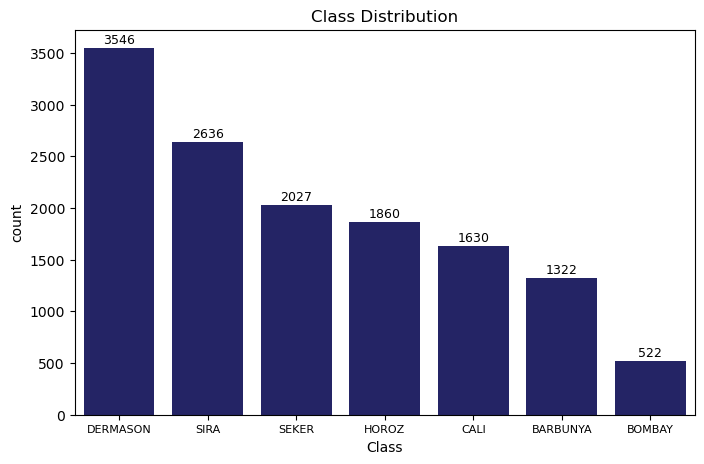

In [8]:
class_counts = df["Class"].value_counts()

plt.figure(figsize=(8,5))

ax = sns.countplot(data=df, x="Class", order=class_counts.index, color="midnightblue")

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height() - 50), ha='center', va='bottom', 
                fontsize=9, xytext=(0, 5), textcoords='offset points')

plt.title("Class Distribution")
plt.xticks(fontsize=8)
plt.show()

### Feature Ranges

In [9]:
numeric_cols = df.select_dtypes(include=np.number).columns

feature_ranges = pd.DataFrame({
    "Min": df[numeric_cols].min(),
    "Max": df[numeric_cols].max(),
    "Range": df[numeric_cols].max() - df[numeric_cols].min()
})

feature_ranges

,Min,Max,Range
Area,20420.000000,254616.000000,234196.000000
Perimeter,524.736000,1985.370000,1460.634000
MajorAxisLength,183.601165,738.860153,555.258988
MinorAxisLength,122.512653,460.198497,337.685843
AspectRation,1.024868,2.430306,1.405439
Eccentricity,0.218951,0.911423,0.692472
ConvexArea,20684.000000,263261.000000,242577.000000
EquivDiameter,161.243764,569.374358,408.130594
Extent,0.555315,0.866195,0.310880
Solidity,0.919246,0.994677,0.075431


### Quantifying Outliers

In [10]:
outlier_summary = {}

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    outlier_summary[col] = round(len(outliers) / len(df) * 100, 2)

pd.DataFrame.from_dict(outlier_summary, orient="index", columns=["Outlier %"])

,Outlier %
Area,4.07
Perimeter,3.69
MajorAxisLength,2.80
MinorAxisLength,4.19
AspectRation,3.58
Eccentricity,6.15
ConvexArea,4.05
EquivDiameter,3.88
Extent,2.00
Solidity,5.72


Outliers were not removed, as they likely represent valid bean variations.

### Separating Features and Target

In [11]:
X = df.drop("Class", axis=1)
y = df["Class"]

### Labeling Our Class Values

In [12]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

label_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
print(label_mapping)

{'BARBUNYA': 0, 'BOMBAY': 1, 'CALI': 2, 'DERMASON': 3, 'HOROZ': 4, 'SEKER': 5, 'SIRA': 6}


### Train/test Split

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=RANDOM_STATE, stratify=y_encoded)

### Standardizing Numeric Features

In [14]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)

X_train_scaled.head()

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4
0,0.560509,1.002462,0.925291,0.503525,0.786671,0.823696,0.582245,0.749885,-0.871715,-2.122169,-1.873432,-0.898136,-0.724272,-1.052294,-0.903132,-2.305622
1,1.017202,1.435815,0.840324,1.520932,-0.547166,-0.300388,1.021247,1.212690,1.562425,-0.541524,-1.746374,0.466374,-1.625335,-0.574239,0.435162,-0.156327
2,0.409630,0.787368,1.159812,-0.074614,2.145667,1.414271,0.403061,0.587300,0.688437,0.452249,-1.582650,-1.853622,-0.103932,-1.404477,-1.755383,-0.495135
3,-0.398662,-0.446283,-0.377380,-0.419042,-0.057031,0.213544,-0.403740,-0.398319,0.863458,0.754599,0.465657,-0.040240,0.349745,0.032920,-0.078360,0.583062
4,1.296921,1.464089,1.627602,1.146080,0.928970,0.903357,1.277206,1.477773,0.804356,1.093852,-0.604207,-0.959023,-1.346560,-1.308562,-0.959527,-0.171608


In [15]:
pd.DataFrame({'mean': X_train_scaled.mean(), 'std': X_train_scaled.std()})

,mean,std
Area,-6.099361e-17,1.000046
Perimeter,2.525004e-16,1.000046
MajorAxisLength,-1.731431e-16,1.000046
MinorAxisLength,-5.220528e-16,1.000046
AspectRation,9.463847e-16,1.000046
Eccentricity,3.633383e-16,1.000046
ConvexArea,1.003443e-16,1.000046
EquivDiameter,-4.453189e-16,1.000046
Extent,-2.675849e-16,1.000046
Solidity,-2.636957e-14,1.000046


After scaling, mean is about 0 for all features, std is about 1

### Correlation

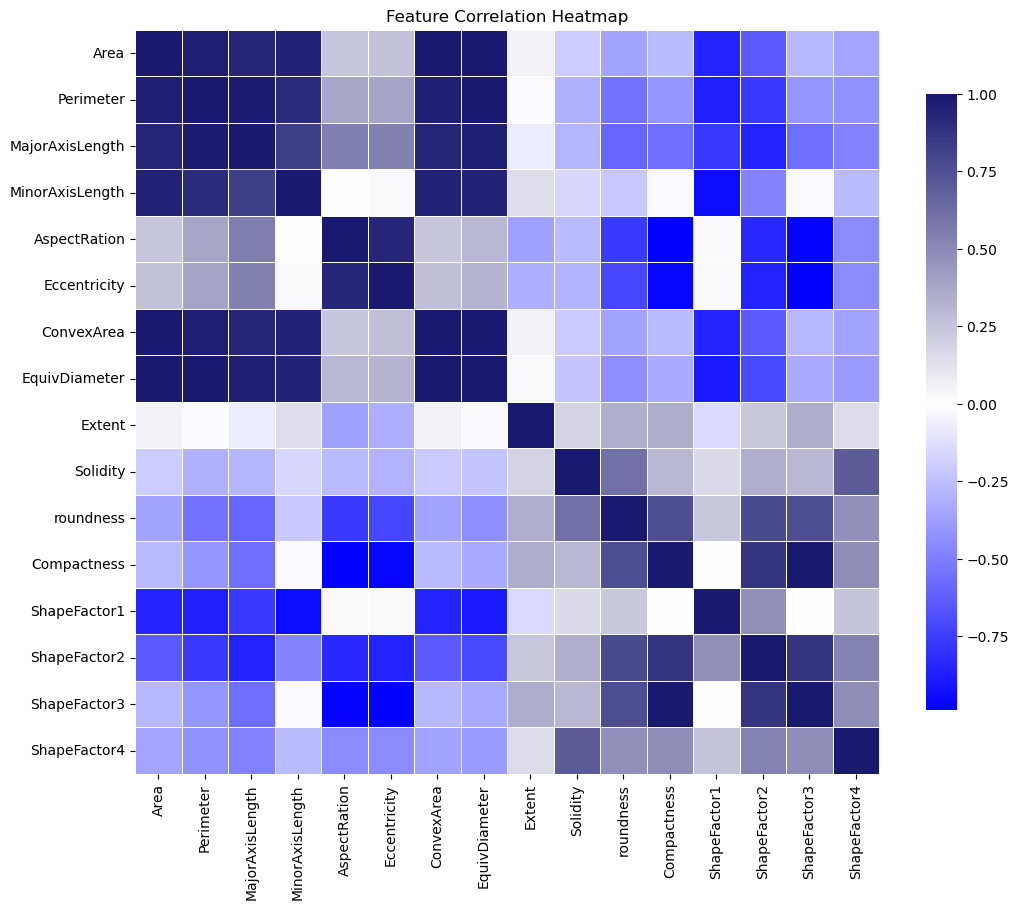

In [16]:
colors = ["blue", "white", "midnightblue"]
custom_cmap = LinearSegmentedColormap.from_list("custom", colors)

plt.figure(figsize=(12,10))
sns.heatmap(df[numeric_cols].corr(), cmap=custom_cmap, center=0, linewidths=0.5, square=True, cbar_kws={"shrink": 0.8})
plt.title("Feature Correlation Heatmap")
plt.show()

### Dropping Highly Correlated Features

In [17]:
#corr_matrix = X_train_scaled.corr().abs()

#upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

#to_drop = [column for column in upper.columns if any(upper[column] > 0.9)]

#print("Dropped features:", to_drop)

#X_train_scaled = X_train_scaled.drop(columns=to_drop)
#X_test_scaled = X_test_scaled.drop(columns=to_drop)

Although several features were highly correlated, removing them slightly reduced classification accuracy. Therefore, the full standardized feature set was kept for classification, while correlation was discussed as a limitation for distance-based methods such as KNN.

## Part 2: Classification

In [18]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

In [19]:
models = {
    "Decision Tree": {
        "model": DecisionTreeClassifier(random_state=RANDOM_STATE),
        "params": {
            "max_depth": [3, 5, 7, 10, None],
            "min_samples_split": [2, 5, 10]
        }
    },
    
    "KNN": {
        "model": KNeighborsClassifier(),
        "params": {
            "n_neighbors": [3, 5, 7, 9, 11],
            "weights": ["uniform", "distance"]
        }
    },
    
    "Naive Bayes": {
        "model": GaussianNB(),
        "params": {
            "var_smoothing": [1e-9, 1e-8, 1e-7, 1e-6]
        }
    }
}

In [20]:
classification_results = []

best_models = {}

for name, item in models.items():
    # 5-fold cross-validation
    grid = GridSearchCV(estimator=item["model"], param_grid=item["params"], cv=5, scoring="f1_macro", n_jobs=-1)
    
    grid.fit(X_train_scaled, y_train)
    
    best_model = grid.best_estimator_
    best_models[name] = best_model
    
    y_pred = best_model.predict(X_test_scaled)
    
    classification_results.append({
        "Model": name,
        "Best Parameters": grid.best_params_,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Macro Precision": precision_score(y_test, y_pred, average="macro"),
        "Macro Recall": recall_score(y_test, y_pred, average="macro"),
        "Macro F1": f1_score(y_test, y_pred, average="macro")
    })

In [21]:
classification_results_df = pd.DataFrame(classification_results)
classification_results_df

,Model,Best Parameters,Accuracy,Macro Precision,Macro Recall,Macro F1
0,Decision Tree,"{'max_depth': 10, 'min_samples_split': 10}",0.904024,0.919064,0.917862,0.918291
1,KNN,"{'n_neighbors': 11, 'weights': 'distance'}",0.914729,0.929156,0.925704,0.927109
2,Naive Bayes,{'var_smoothing': 1e-09},0.897010,0.908075,0.908248,0.907220


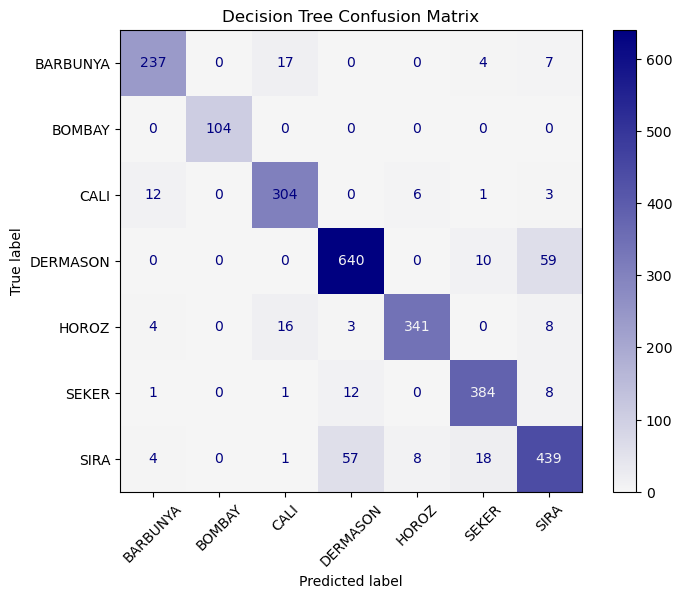

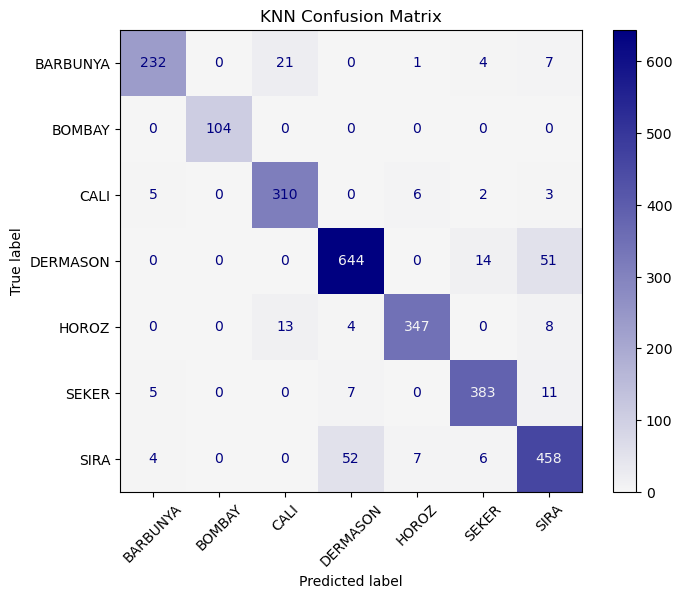

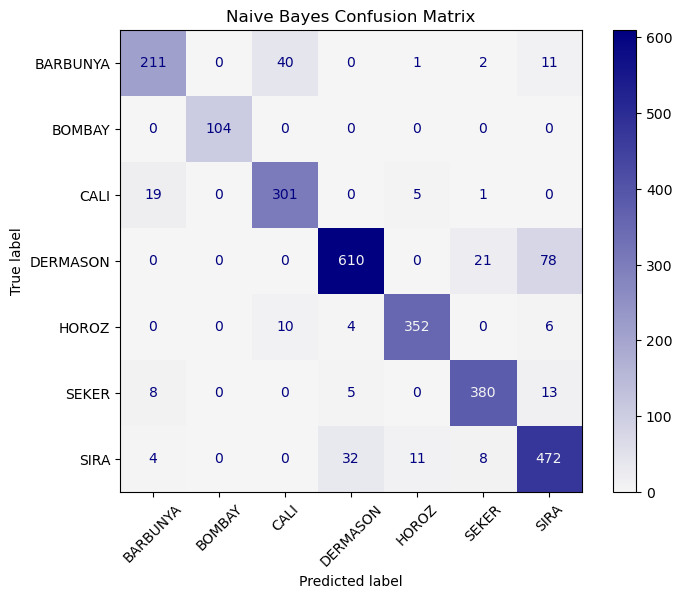

In [22]:
cm_cmap = LinearSegmentedColormap.from_list("midnightblue_white", ["#f5f5f5", "#000080"])

for name, model in best_models.items():
    y_pred = model.predict(X_test_scaled)
    
    cm = confusion_matrix(y_test, y_pred)
    
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=label_encoder.classes_
    )
    
    fig, ax = plt.subplots(figsize=(8, 6))
    disp.plot(ax=ax, cmap=cm_cmap, xticks_rotation=45, colorbar=True)
    plt.title(f"{name} Confusion Matrix")
    plt.show()

## Part 3: Clustering

In [23]:
import time
import warnings
import matplotlib.cm as cm

from sklearn.cluster import KMeans
from sklearn_extra.cluster import KMedoids
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.metrics import precision_score, recall_score, f1_score
from scipy.stats import entropy

warnings.filterwarnings("ignore")

### Scaling the full dataset

In [24]:
scaler_clustering = StandardScaler()
X_scaled_clustering = scaler_clustering.fit_transform(X)

X_scaled_clustering = pd.DataFrame(X_scaled_clustering, columns=X.columns)

Clustering tendency was not measured separately because the dataset already contains known class labels. The main goal here is not to prove that clusters exist, but to test how well unsupervised clustering can recover the seven known bean varieties.

In [25]:
k_values = range(2, 11)

inertias = []
silhouette_scores = []

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        init="k-means++",
        random_state=RANDOM_STATE,
        n_init=10
    )
    
    cluster_labels = kmeans.fit_predict(X_scaled_clustering)
    
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(
        silhouette_score(
            X_scaled_clustering,
            cluster_labels,
            sample_size=2000,
            random_state=RANDOM_STATE
        )
    )

In [26]:
k_selection_table = pd.DataFrame({
    "k": list(k_values),
    "Inertia": inertias,
    "Silhouette Score": silhouette_scores
})

k_selection_table

,k,Inertia,Silhouette Score
0,2,129194.019862,0.393705
1,3,94331.734651,0.404621
2,4,75993.194923,0.343376
3,5,61624.637418,0.360888
4,6,54900.748279,0.358400
5,7,48671.457043,0.313019
6,8,45083.358973,0.305689
7,9,41904.816088,0.307286
8,10,39707.125849,0.270791


### Elbow Method

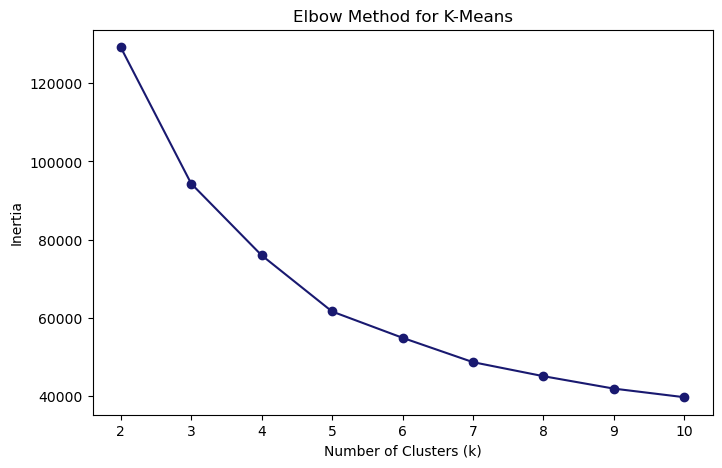

In [27]:
plt.figure(figsize=(8,5))
plt.plot(k_selection_table["k"], k_selection_table["Inertia"], marker="o", color="midnightblue")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for K-Means")
plt.show()

### Silhouette Analysis

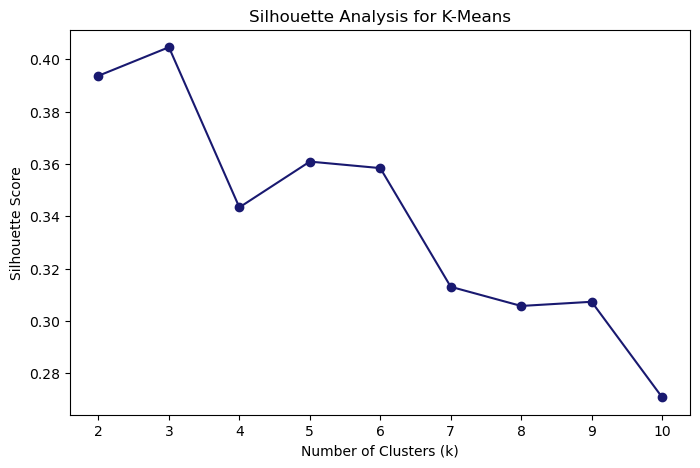

In [28]:
plt.figure(figsize=(8,5))
plt.plot(k_selection_table["k"], k_selection_table["Silhouette Score"], marker="o", color="midnightblue")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Analysis for K-Means")
plt.show()

### Detailed silhouette plot adapted from scikit-learn example
### Source: https://scikit-learn.org/stable/auto_examples/cluster/plot_kmeans_silhouette_analysis.html

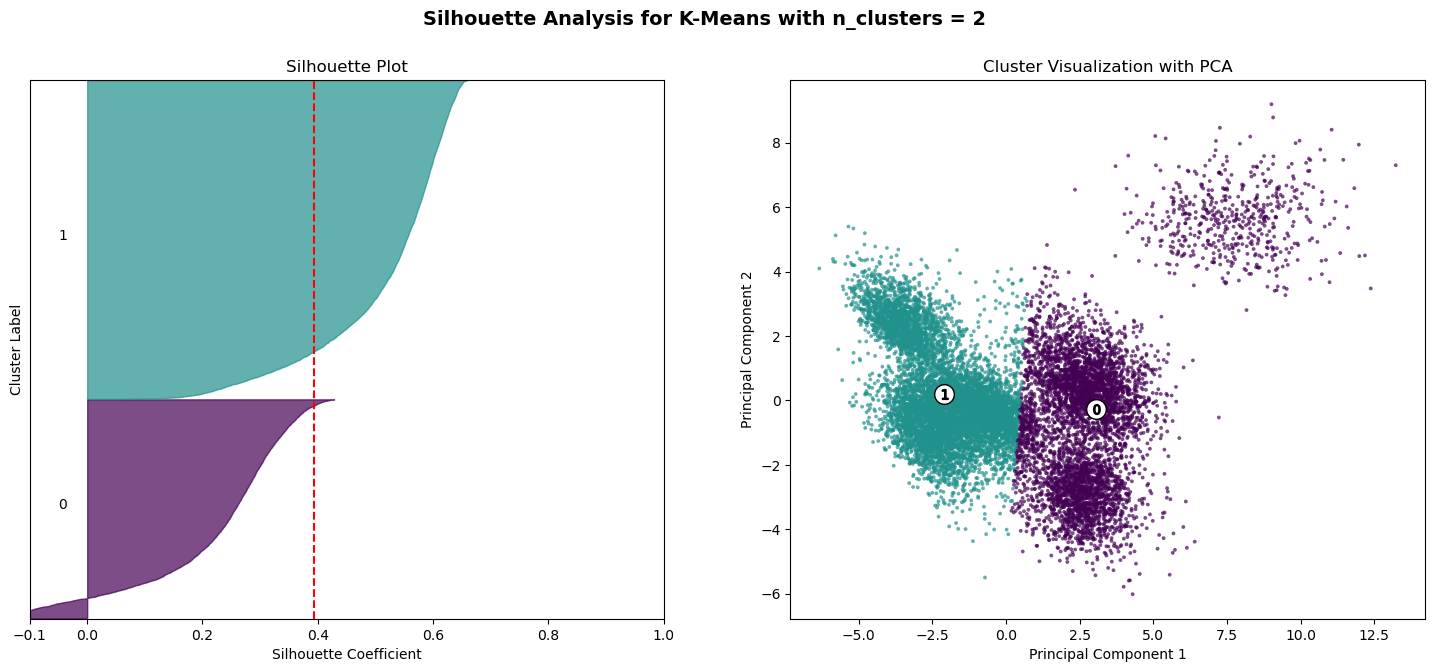

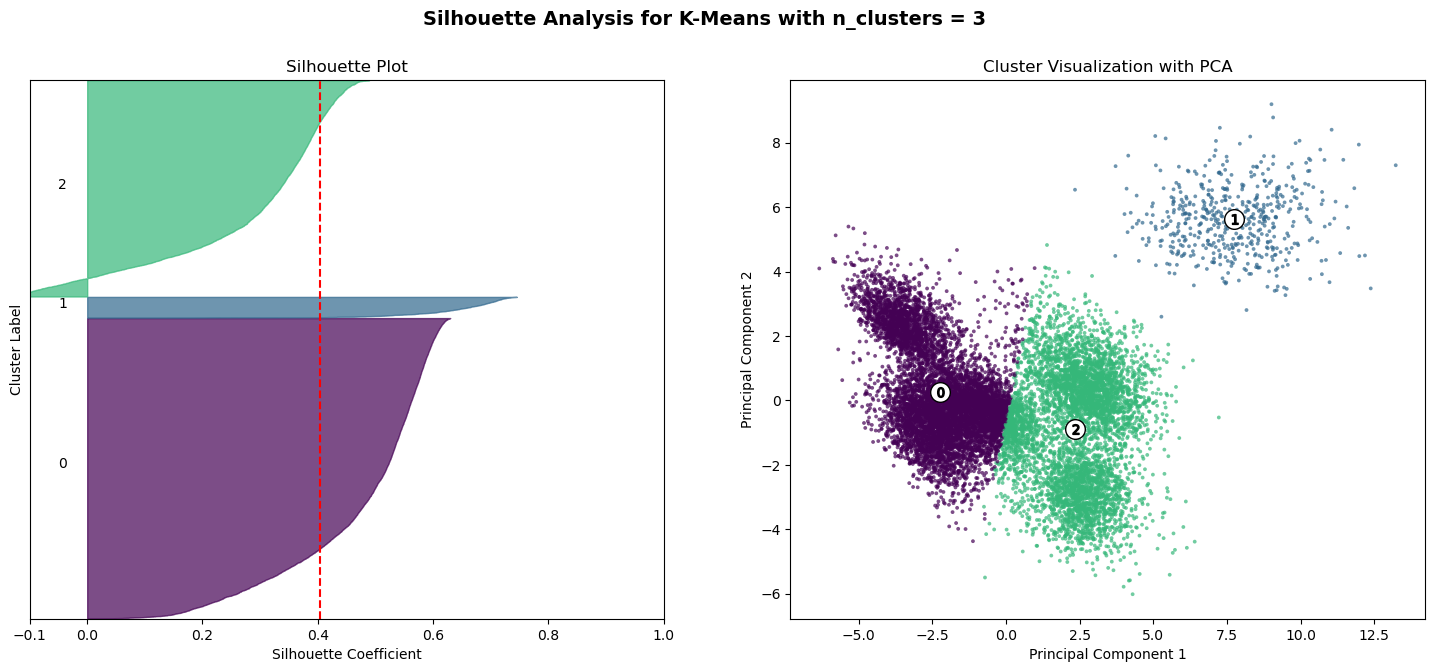

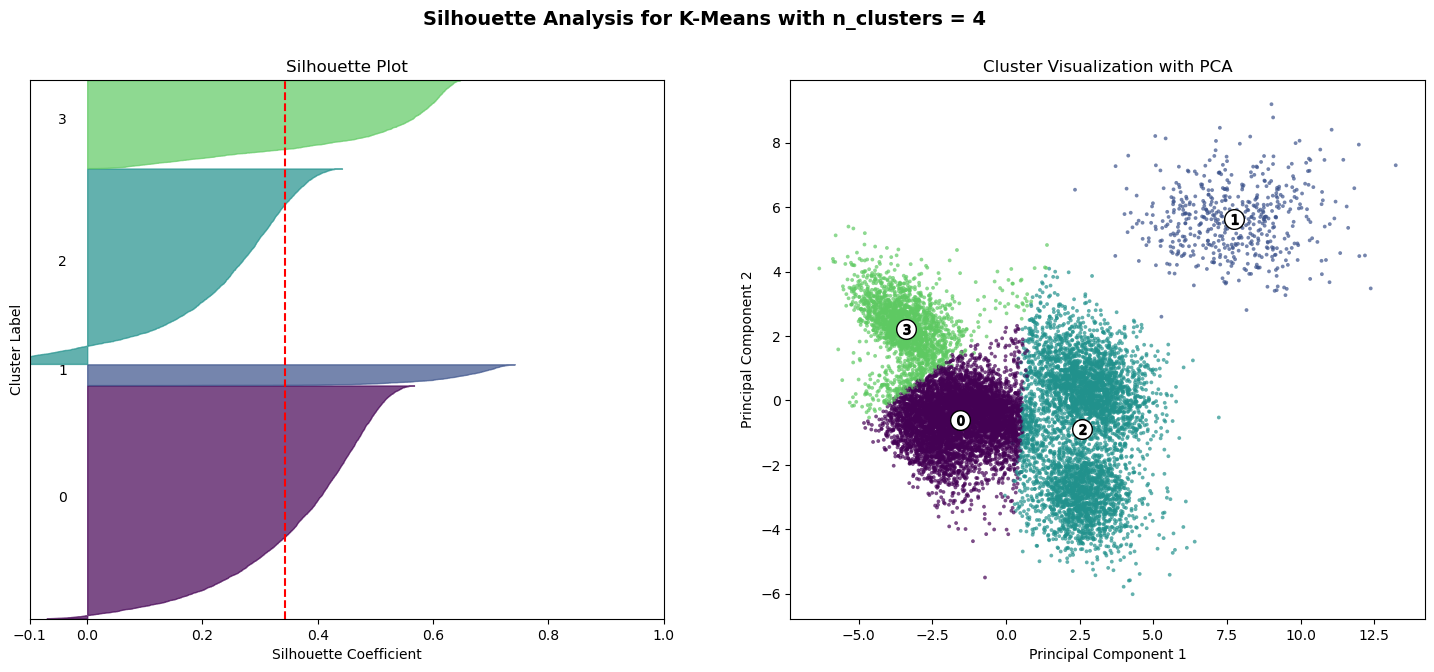

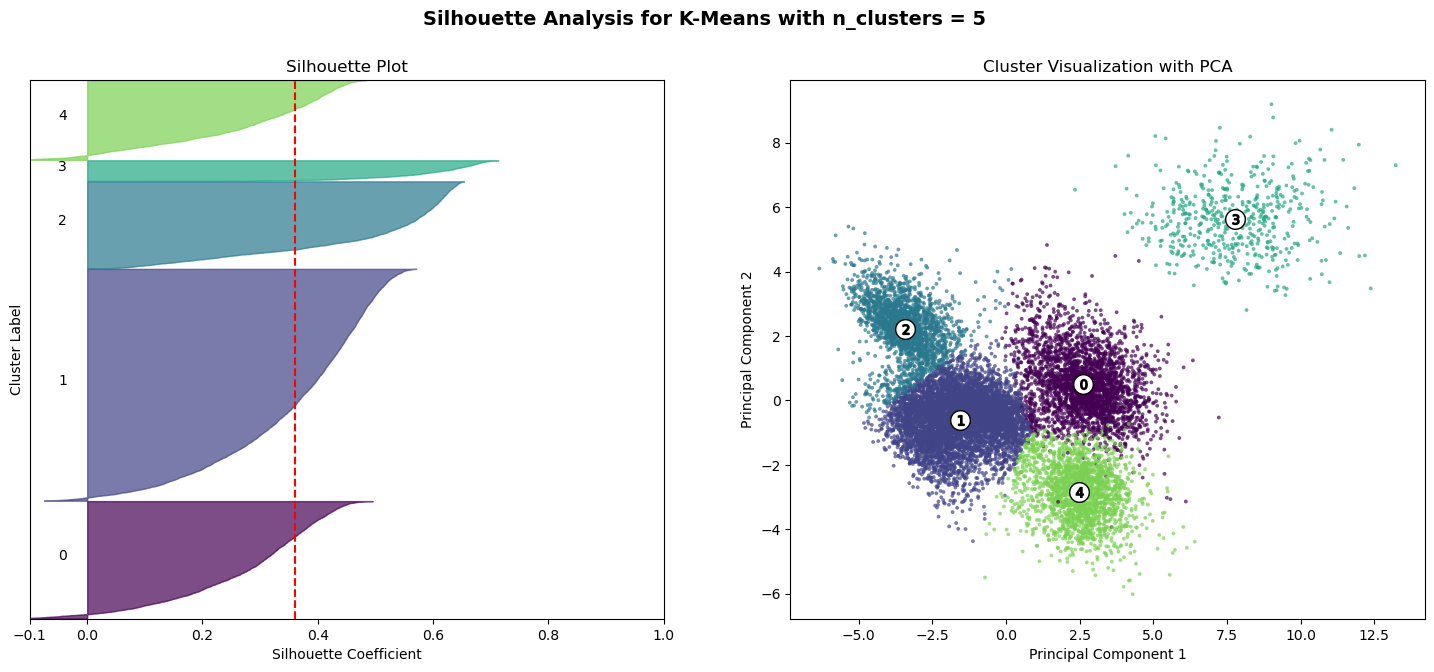

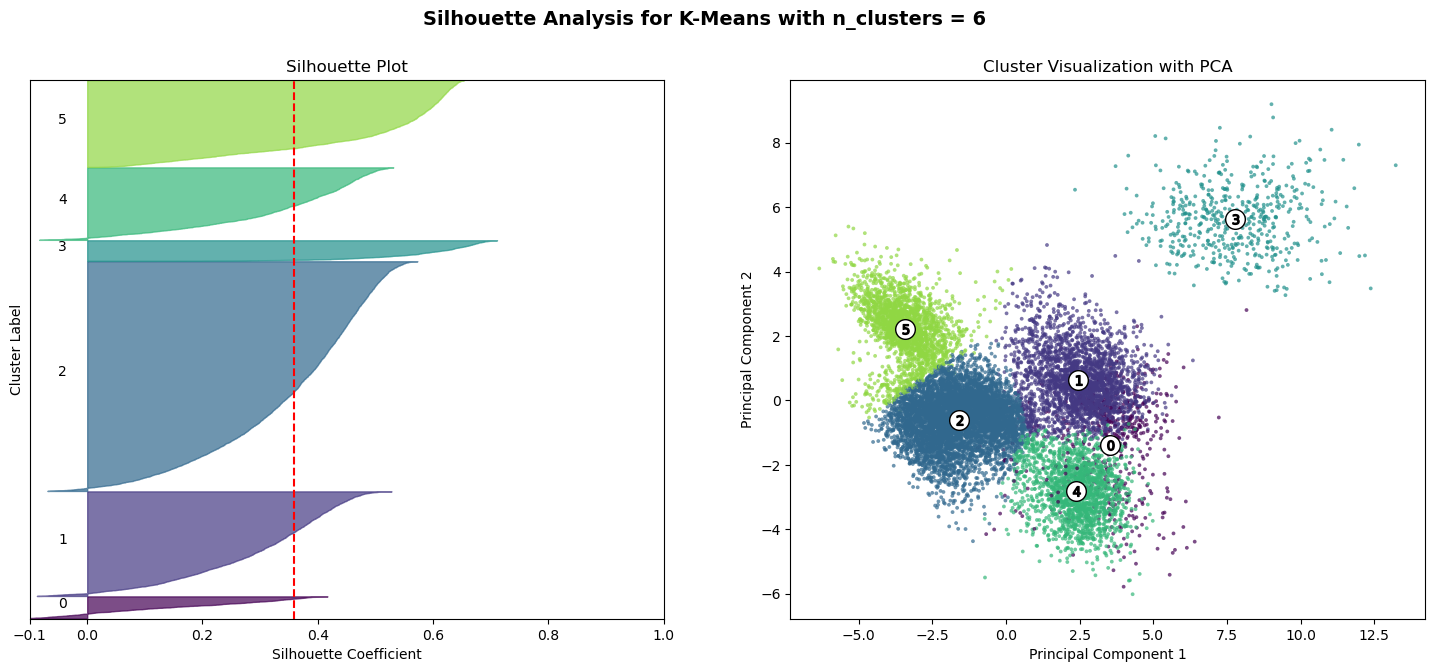

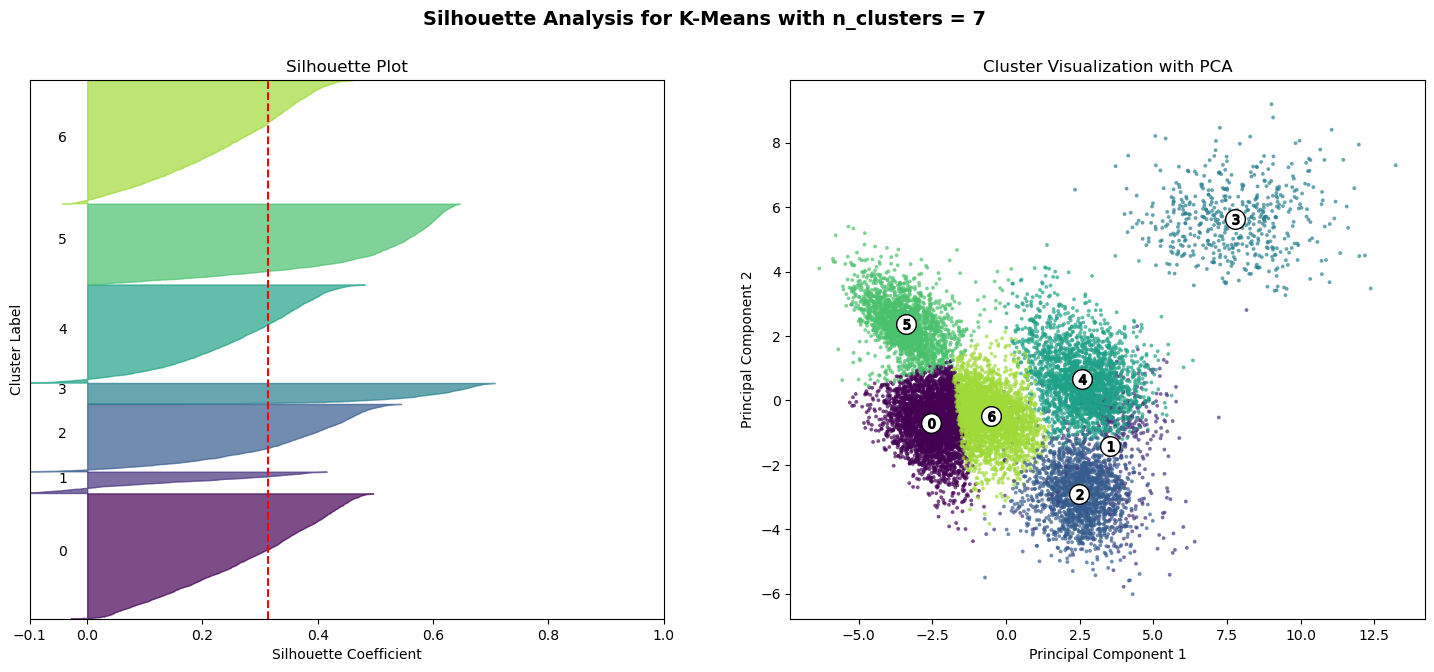

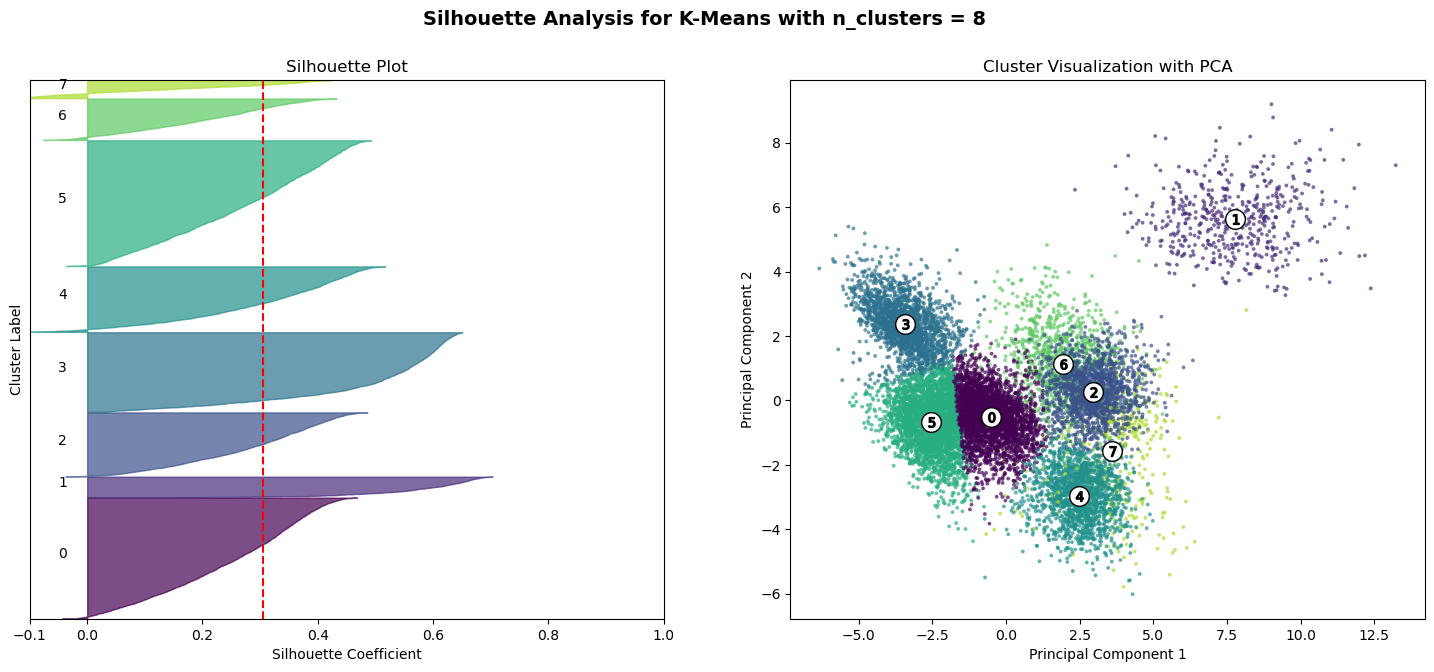

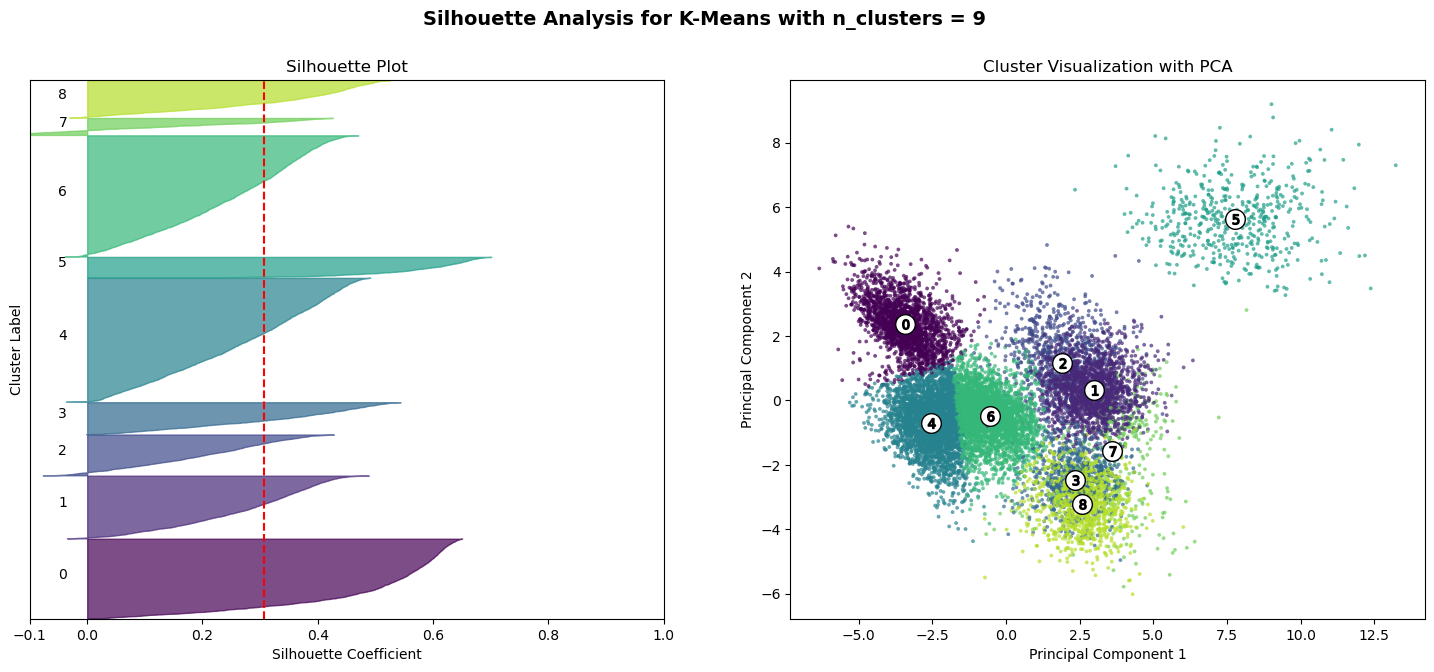

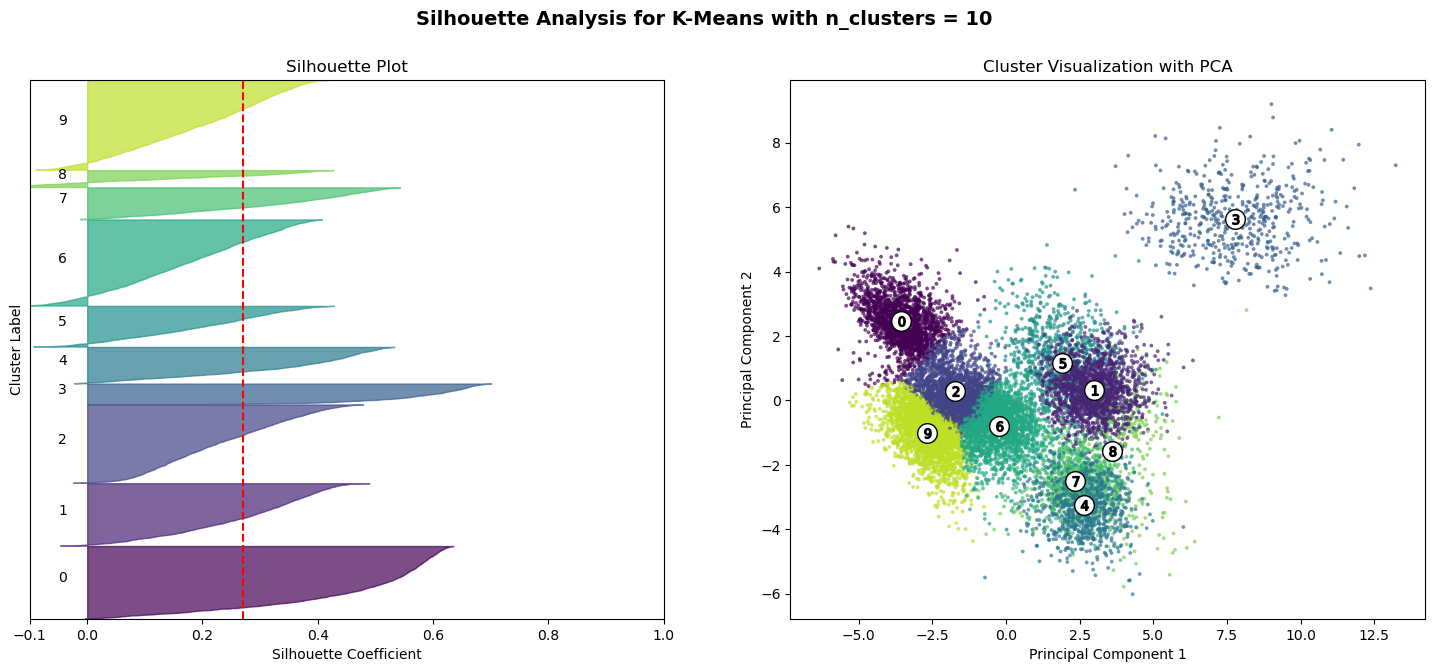

In [29]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled_clustering)

range_n_clusters = [2, 3, 4, 5, 6, 7, 8, 9, 10]

for n_clusters in range_n_clusters:
    fig, (ax1, ax2) = plt.subplots(1, 2)
    fig.set_size_inches(18, 7)

    ax1.set_xlim([-0.1, 1])
    ax1.set_ylim([0, len(X_scaled_clustering) + (n_clusters + 1) * 10])

    clusterer = KMeans(
        n_clusters=n_clusters,
        init="k-means++",
        random_state=RANDOM_STATE,
        n_init=10
    )

    cluster_labels = clusterer.fit_predict(X_scaled_clustering)

    silhouette_avg = silhouette_score(
        X_scaled_clustering,
        cluster_labels,
        sample_size=2000,
        random_state=RANDOM_STATE
    )

    sample_silhouette_values = silhouette_samples(
        X_scaled_clustering,
        cluster_labels
    )

    y_lower = 10

    for i in range(n_clusters):
        ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]
        ith_cluster_silhouette_values.sort()

        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i

        color = cm.viridis(float(i) / n_clusters)

        ax1.fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            ith_cluster_silhouette_values,
            facecolor=color,
            edgecolor=color,
            alpha=0.7
        )

        ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
        y_lower = y_upper + 10

    ax1.axvline(x=silhouette_avg, color="red", linestyle="--")

    ax1.set_title("Silhouette Plot")
    ax1.set_xlabel("Silhouette Coefficient")
    ax1.set_ylabel("Cluster Label")
    ax1.set_yticks([])
    ax1.set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])

    colors = cm.viridis(cluster_labels.astype(float) / n_clusters)

    ax2.scatter(
        X_pca[:, 0],
        X_pca[:, 1],
        marker=".",
        s=30,
        lw=0,
        alpha=0.7,
        c=colors,
        edgecolor="k"
    )

    centers_pca = pca.transform(clusterer.cluster_centers_)

    ax2.scatter(
        centers_pca[:, 0],
        centers_pca[:, 1],
        marker="o",
        c="white",
        alpha=1,
        s=200,
        edgecolor="k"
    )

    for i, c in enumerate(centers_pca):
        ax2.scatter(
            c[0],
            c[1],
            marker=f"${i}$",
            alpha=1,
            s=50,
            edgecolor="k"
        )

    ax2.set_title("Cluster Visualization with PCA")
    ax2.set_xlabel("Principal Component 1")
    ax2.set_ylabel("Principal Component 2")

    plt.suptitle(
        f"Silhouette Analysis for K-Means with n_clusters = {n_clusters}",
        fontsize=14,
        fontweight="bold"
    )

    plt.show()

### Selected Number of Clusters

In [30]:
selected_k = 7

Although the elbow method and silhouette analysis suggest fewer clusters, selected_k = 7 was used because the Dry Bean dataset contains seven known bean classes. This allows external evaluation by comparing the produced clusters against the true bean varieties.

### Defining Clustering Models

In [31]:
clustering_models = {
    "K-Means Random": KMeans(
        n_clusters=selected_k,
        init="random",
        random_state=RANDOM_STATE,
        n_init=10
    ),
    
    "K-Means++": KMeans(
        n_clusters=selected_k,
        init="k-means++",
        random_state=RANDOM_STATE,
        n_init=10
    ),

    # Alternative to K-Mediods PAM because it takes 3+ minutes
    #"K-Medoids Alternate": KMedoids(
    #n_clusters=selected_k,
    #method="alternate",
    #init="k-medoids++",
    #random_state=RANDOM_STATE
    #),
    
    "K-Medoids PAM": KMedoids(
        n_clusters=selected_k,
        method="pam",
        init="k-medoids++",
        random_state=RANDOM_STATE
    )
}

### Evaluation Functions

In [32]:
def calculate_cohesion(X, labels):
    cohesion = {}

    for cluster in np.unique(labels):
        cluster_points = X[labels == cluster]
        centroid = cluster_points.mean(axis=0)
        distances = np.linalg.norm(cluster_points - centroid, axis=1)
        cohesion[cluster] = np.sum(distances ** 2)

    return cohesion

def calculate_cohesiveness(X, labels):
    cohesiveness = 0
    
    for cluster in np.unique(labels):
        cluster_points = X[labels == cluster]
        centroid = cluster_points.mean(axis=0)
        distances = np.linalg.norm(cluster_points - centroid, axis=1)
        cohesiveness += np.sum(distances ** 2)
    
    return cohesiveness


def calculate_separateness(X, labels):
    overall_centroid = X.mean(axis=0)
    separateness = 0
    
    for cluster in np.unique(labels):
        cluster_points = X[labels == cluster]
        cluster_centroid = cluster_points.mean(axis=0)
        distance = np.linalg.norm(cluster_centroid - overall_centroid)
        separateness += len(cluster_points) * (distance ** 2)
    
    return separateness


def purity_score(y_true, cluster_labels):
    contingency_matrix = pd.crosstab(cluster_labels, y_true)
    return np.sum(np.max(contingency_matrix.values, axis=1)) / np.sum(contingency_matrix.values)


def entropy_score(y_true, cluster_labels):
    contingency_matrix = pd.crosstab(cluster_labels, y_true)
    total = contingency_matrix.values.sum()
    weighted_entropy = 0
    
    for cluster_counts in contingency_matrix.values:
        cluster_total = cluster_counts.sum()
        
        if cluster_total == 0:
            continue
        
        probabilities = cluster_counts / cluster_total
        weighted_entropy += (cluster_total / total) * entropy(probabilities, base=2)
    
    return weighted_entropy


def map_clusters_to_classes(y_true, cluster_labels):
    mapping = {}
    
    for cluster in np.unique(cluster_labels):
        true_labels_in_cluster = y_true[cluster_labels == cluster]
        majority_class = np.bincount(true_labels_in_cluster).argmax()
        mapping[cluster] = majority_class
    
    mapped_predictions = np.array([mapping[cluster] for cluster in cluster_labels])
    
    return mapped_predictions, mapping

### Clustering Process

In [33]:
cohesion_results = []
internal_results = []
external_results = []
cluster_labels_dict = {}
cluster_mapping_dict = {}

X_cluster_np = X_scaled_clustering.values

for name, model in clustering_models.items():
    start_time = time.perf_counter()
    
    labels = model.fit_predict(X_cluster_np)

    cluster_cohesion = calculate_cohesion(X_cluster_np, labels)

    for cluster, cohesion in cluster_cohesion.items():
        cohesion_results.append({
        "Model": name,
        "Cluster": cluster,
        "Cohesion": cohesion
        })
    
    end_time = time.perf_counter()
    runtime_minutes = (end_time - start_time) / 60
    
    cluster_labels_dict[name] = labels
    
    mapped_preds, mapping = map_clusters_to_classes(y_encoded, labels)
    cluster_mapping_dict[name] = mapping
    
    internal_results.append({
        "Model": name,
        "Runtime (minutes)": round(runtime_minutes, 3),
        "Silhouette Score": silhouette_score(
            X_cluster_np,
            labels,
            sample_size=2000,
            random_state=RANDOM_STATE
        ),
        "Cohesiveness": calculate_cohesiveness(X_cluster_np, labels),
        "Separateness": calculate_separateness(X_cluster_np, labels)
    })
    
    external_results.append({
        "Model": name,
        "Purity": purity_score(y_encoded, labels),
        "Entropy": entropy_score(y_encoded, labels),
        "Macro Precision": precision_score(y_encoded, mapped_preds, average="macro", zero_division=0),
        "Macro Recall": recall_score(y_encoded, mapped_preds, average="macro", zero_division=0),
        "Macro F1": f1_score(y_encoded, mapped_preds, average="macro", zero_division=0)
    })

### Internal Evaluation

In [45]:
cohesiveness_per_cluster_df = pd.DataFrame(cohesion_results)
cohesiveness_per_cluster_df

,Model,Cluster,Cohesiveness
0,K-Means Random,0,8163.562876
1,K-Means Random,1,5542.743102
2,K-Means Random,2,11582.410752
3,K-Means Random,3,7458.023454
4,K-Means Random,4,4484.758097
5,K-Means Random,5,3384.662758
6,K-Means Random,6,8055.291980
7,K-Means++,0,7458.023454
8,K-Means++,1,5542.743102
9,K-Means++,2,8055.291980


In [34]:
internal_results_df = pd.DataFrame(internal_results)
internal_results_df

,Model,Runtime (minutes),Silhouette Score,Cohesiveness,Separateness
0,K-Means Random,0.003,0.313019,48671.453019,168016.546981
1,K-Means++,0.003,0.313019,48671.453019,168016.546981
2,K-Medoids PAM,8.079,0.296301,52070.828112,164617.171888


### External Evaluation Table

In [35]:
external_results_df = pd.DataFrame(external_results)
external_results_df

,Model,Purity,Entropy,Macro Precision,Macro Recall,Macro F1
0,K-Means Random,0.797608,0.784822,0.721549,0.778308,0.738988
1,K-Means++,0.797608,0.784822,0.721549,0.778308,0.738988
2,K-Medoids PAM,0.802038,0.819236,0.716816,0.782179,0.741811


### Cluster vs True Classs Matrices

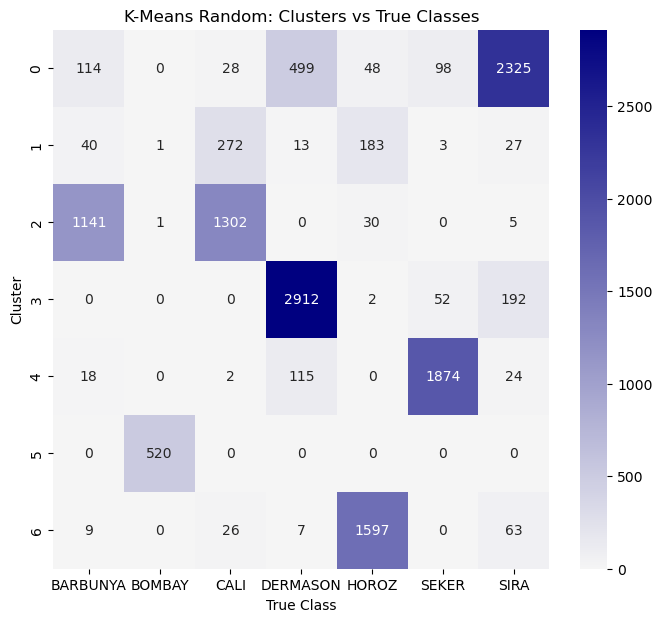

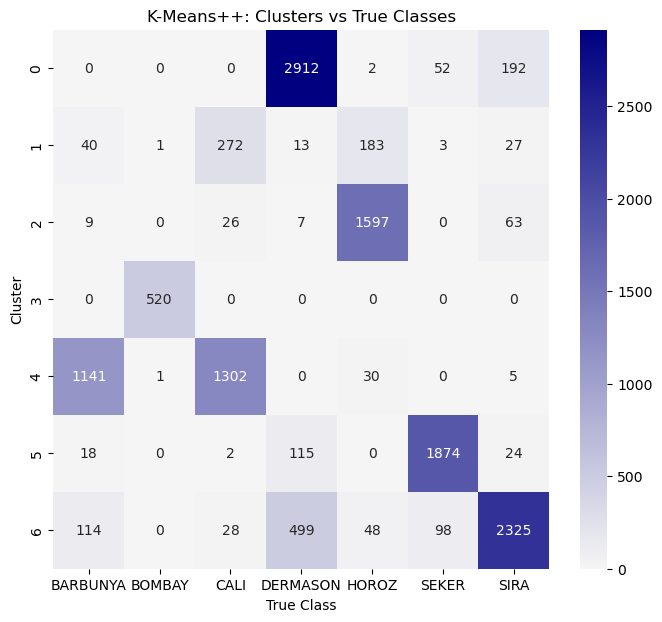

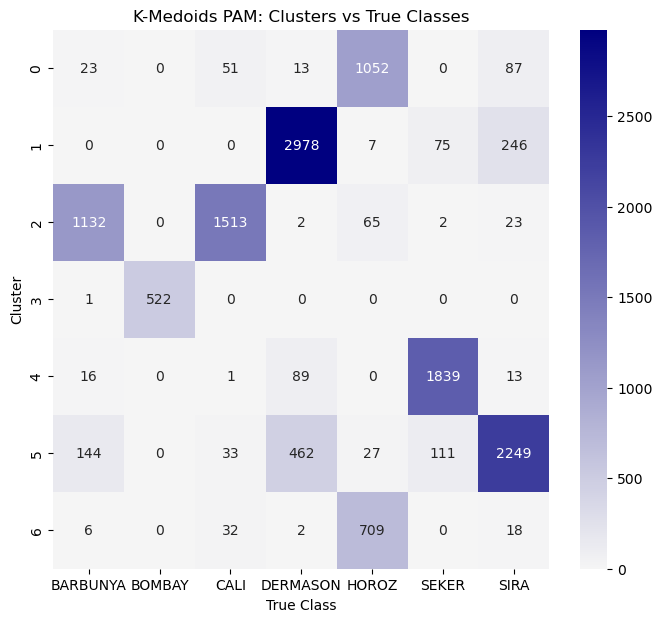

In [36]:
for name, labels in cluster_labels_dict.items():
    cluster_class_table = pd.crosstab(
        pd.Series(labels, name="Cluster"),
        pd.Series(y, name="True Class")
    )
    
    plt.figure(figsize=(8,7))
    sns.heatmap(
        cluster_class_table,
        annot=True,
        fmt="d",
        cmap=cm_cmap
    )
    plt.title(f"{name}: Clusters vs True Classes")
    plt.xlabel("True Class")
    plt.ylabel("Cluster")
    plt.show()

### PCA Cluster Visualization

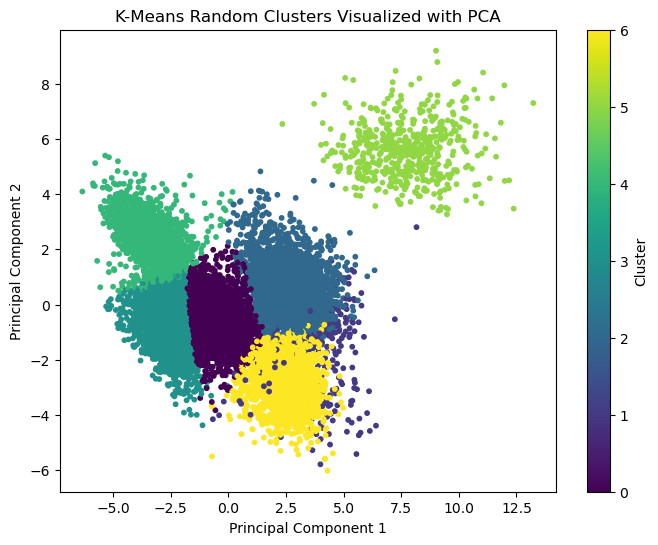

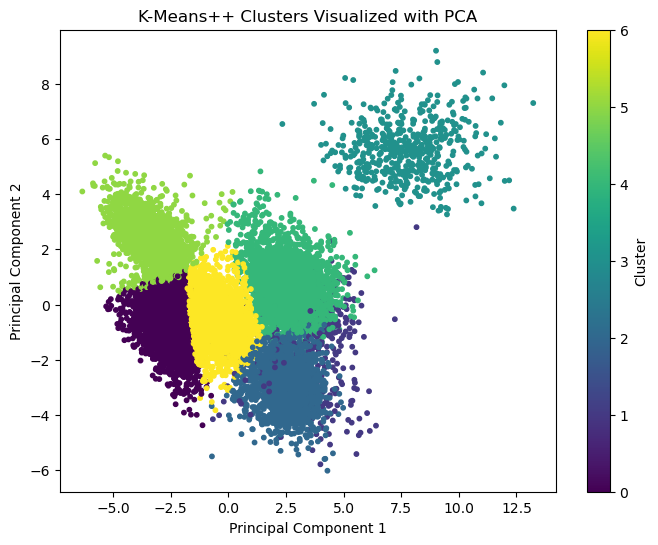

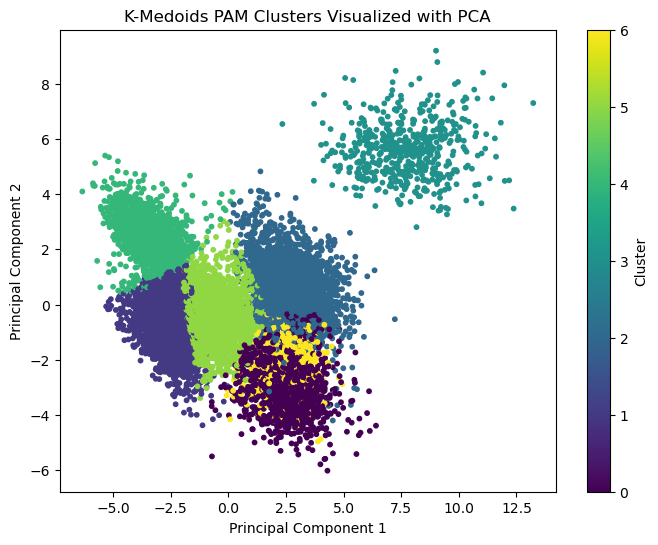

In [37]:
for name, labels in cluster_labels_dict.items():
    plt.figure(figsize=(8,6))
    plt.scatter(
        X_pca[:, 0],
        X_pca[:, 1],
        c=labels,
        cmap="viridis",
        s=10
    )
    plt.xlabel("Principal Component 1")
    plt.ylabel("Principal Component 2")
    plt.title(f"{name} Clusters Visualized with PCA")
    plt.colorbar(label="Cluster")
    plt.show()

## Part 4: Comparison and discussion

### Classification Summary Table

In [38]:
classification_summary = classification_results_df.copy()

classification_summary = classification_summary[
    ["Model", "Accuracy", "Macro Precision", "Macro Recall", "Macro F1", "Best Parameters"]
]

classification_summary

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,Best Parameters
0,Decision Tree,0.904024,0.919064,0.917862,0.918291,"{'max_depth': 10, 'min_samples_split': 10}"
1,KNN,0.914729,0.929156,0.925704,0.927109,"{'n_neighbors': 11, 'weights': 'distance'}"
2,Naive Bayes,0.897010,0.908075,0.908248,0.907220,{'var_smoothing': 1e-09}


### Internal Clustering Summary Table

In [39]:
internal_clustering_summary = internal_results_df.copy()

internal_clustering_summary = internal_clustering_summary[
    ["Model", "Runtime (minutes)", "Silhouette Score", "Cohesiveness", "Separateness"]
]

internal_clustering_summary

,Model,Runtime (minutes),Silhouette Score,Cohesiveness,Separateness
0,K-Means Random,0.003,0.313019,48671.453019,168016.546981
1,K-Means++,0.003,0.313019,48671.453019,168016.546981
2,K-Medoids PAM,8.079,0.296301,52070.828112,164617.171888


### External Clustering Summary Table

In [40]:
external_clustering_summary = external_results_df.copy()

external_clustering_summary = external_clustering_summary[
    ["Model", "Purity", "Entropy", "Macro Precision", "Macro Recall", "Macro F1"]
]

external_clustering_summary

,Model,Purity,Entropy,Macro Precision,Macro Recall,Macro F1
0,K-Means Random,0.797608,0.784822,0.721549,0.778308,0.738988
1,K-Means++,0.797608,0.784822,0.721549,0.778308,0.738988
2,K-Medoids PAM,0.802038,0.819236,0.716816,0.782179,0.741811


### Combined Best-model Comparison Table

In [41]:
best_classifier = classification_results_df.loc[
    classification_results_df["Macro F1"].idxmax()
]

best_clusterer = external_results_df.loc[
    external_results_df["Macro F1"].idxmax()
]

best_internal_clusterer = internal_results_df.loc[
    internal_results_df["Silhouette Score"].idxmax()
]

print("\033[1m" + "Best Classifier" + "\033[0m")
print(best_classifier, '\n')

print("\033[1m" + "Best Clusterer" + "\033[0m")
print(best_clusterer, '\n')

print("\033[1m" + "Best Internal Clusterer" + "\033[0m")
print(best_internal_clusterer)

Best Classifier
Model                                                     KNN
Best Parameters    {'n_neighbors': 11, 'weights': 'distance'}
Accuracy                                             0.914729
Macro Precision                                      0.929156
Macro Recall                                         0.925704
Macro F1                                             0.927109
Name: 1, dtype: object 

Best Clusterer
Model              K-Medoids PAM
Purity                  0.802038
Entropy                 0.819236
Macro Precision         0.716816
Macro Recall            0.782179
Macro F1                0.741811
Name: 2, dtype: object 

Best Internal Clusterer
Model                K-Means Random
Runtime (minutes)             0.003
Silhouette Score           0.313019
Cohesiveness           48671.453019
Separateness          168016.546981
Name: 0, dtype: object


In [42]:
comparison_table = pd.DataFrame({
    "Approach": ["Classification", "Clustering"],
    "Best Method": [best_classifier["Model"], best_clusterer["Model"]],
    "Main Evaluation Metric": ["Macro F1", "Macro F1"],
    "Score": [best_classifier["Macro F1"], best_clusterer["Macro F1"]]
})

comparison_table

,Approach,Best Method,Main Evaluation Metric,Score
0,Classification,KNN,Macro F1,0.927109
1,Clustering,K-Medoids PAM,Macro F1,0.741811


### Discussion

The supervised classification models performed better than the unsupervised clustering methods overall. Among the classifiers, KNN achieved the best performance, with the highest accuracy and macro F1-score. This suggests that the Dry Bean dataset has a feature space where nearby samples often belong to the same bean variety. Since KNN is distance-based, the standardization step was important because the original features had very different ranges. Without standardization, large-scale features such as Area, Perimeter, and ConvexArea would dominate the distance calculations.

The Decision Tree also performed well, but slightly worse than KNN. This is expected because decision trees split the feature space using threshold rules, which can work well for shape measurements but may not capture smooth distance-based class boundaries as effectively as KNN. Naive Bayes had the lowest classification performance among the three models, likely because its independence assumption is too strong for this dataset. Many of the geometric features are correlated, such as Area, Perimeter, ConvexArea, and EquivDiameter, so the Naive Bayes assumption that features are conditionally independent is not fully realistic.

For clustering, K-Means, K-Means++, and K-Medoids were evaluated using internal and external measures. The internal metrics showed that K-Means and K-Means++ produced the best silhouette score and lower cohesiveness than K-Medoids, meaning their clusters were more compact and better separated according to distance-based criteria. However, the external evaluation showed that K-Medoids slightly better recovered the true class structure, with the highest purity and macro F1 after mapping each cluster to its majority true class.

The elbow and silhouette analysis did not strongly support seven clusters. The silhouette score was highest for smaller values of k, especially k = 3, while k = 7 had a lower silhouette score. This suggests that although the dataset contains seven true bean varieties, the natural geometric structure of the data may group some varieties together. In other words, some bean classes are close or overlapping in feature space, so unsupervised clustering has difficulty separating them into the exact seven labeled categories.

Overall, the classification methods were much better at recovering the true bean classes than clustering. This is expected because classification uses the true labels during training, while clustering only uses feature similarity. The results show that the class labels contain useful information that is not fully recoverable from unsupervised distance-based grouping alone. Preprocessing had an important effect on both tasks: standardization was necessary for KNN, K-Means, and K-Medoids because all three rely on distance calculations. Highly correlated features were investigated, but removing them slightly reduced classification accuracy, so the full standardized feature set was kept.

### Hyperparameter Justification

For classification, GridSearchCV with 5-fold cross-validation was used to tune key hyperparameters for each model. 
For Decision Tree, `max_depth` and `min_samples_split` were tuned to control model complexity and reduce overfitting. 
For KNN, `n_neighbors` and `weights` were tuned because they directly affect how nearby samples influence the prediction. 
For Naive Bayes, `var_smoothing` was tuned to improve numerical stability.

For clustering, the number of clusters was investigated using the elbow method and silhouette analysis. Although the internal metrics suggested fewer clusters, `k = 7` was selected for the final clustering models because the Dry Bean dataset contains seven known bean varieties. This allowed the clusters to be externally evaluated against the hidden true labels. K-Means was tested with both random and K-Means++ initialization, while K-Medoids PAM was included because it uses actual data points as cluster centers and can be more robust to unusual observations.